# Código atualizado


In [1]:
# ============================================
# 0) Imports
# ============================================
import warnings
import os
import shutil
import pandas as pd
import numpy as np

from dataclasses import dataclass

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [2]:
# ============================================
# Configuração do diretório de saída
# ============================================
OUTPUT_DIR = 'output'
CATBOOST_DIR = 'catboost_info'

if not os.path.exists(OUTPUT_DIR):
    # Se não existe, cria a pasta
    os.makedirs(OUTPUT_DIR)
    print(f"Pasta '{OUTPUT_DIR}' criada com sucesso.")
else:
    # Se existe, itera sobre os arquivos e remove-os
    print(f"Limpando arquivos existentes em '{OUTPUT_DIR}'...")
    for filename in os.listdir(OUTPUT_DIR):
        file_path = os.path.join(OUTPUT_DIR, filename)
        try:
            # Verifica se é um arquivo ou link simbólico para remover
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            # Se for um diretório dentro da pasta output, remove-o e seu conteúdo
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f'Falha ao deletar {file_path}. Motivo: {e}')
    print(f"Pasta '{OUTPUT_DIR}' está limpa e pronta para uso.")

# Remoção específica da pasta 'catboost_info'
if os.path.exists(CATBOOST_DIR):
    try:
        shutil.rmtree(CATBOOST_DIR)
        print(f"Pasta '{CATBOOST_DIR}' removida com sucesso.")
    except Exception as e:
        print(f"Não foi possível remover '{CATBOOST_DIR}'. Motivo: {e}")

print(f"😎 Ambiente pronto para nova execução.")

Limpando arquivos existentes em 'output'...
Pasta 'output' está limpa e pronta para uso.
😎 Ambiente pronto para nova execução.


In [ ]:
# ============================================
# 1) Constantes
# ============================================
DATASET_HC = 'data/dataset_voz_completo_HC.csv'
DATASET_PD = 'data/dataset_voz_completo_PD.csv'
DATASET_CONCAT = OUTPUT_DIR + '/dataset_concatenado.csv'
DATASET_TSALLIS = OUTPUT_DIR + '/dataset_tsallis.csv'
DATASET_REDUCED = OUTPUT_DIR + '/dataset_reduced.csv'
DATASET_IMPUTED = OUTPUT_DIR + '/dataset_imputed.csv'

CORRELATION_THRESHOLD = 0.9
CORRELATION_LIST = OUTPUT_DIR + '/lista_correlacao_completa.csv'
CORRELATION_GRAPH = OUTPUT_DIR + '/correlation_heatmap_completo.png'

CONSENSUS_RANKING = OUTPUT_DIR + '/ranking_importancia_completo.csv'
CONSENSUS_TOP_K = 16

In [ ]:
# ============================================
# 1) Carregar datasets
# ============================================
df_HC = pd.read_csv(DATASET_HC)
df_PD = pd.read_csv(DATASET_PD)
print("Shape original HC:", df_HC.shape)
print("Shape original DF:", df_PD.shape)

df_HC['status'] = 0
df_PD['status'] = 1

df_concat = pd.concat([df_HC, df_PD], ignore_index=True)
print("Shape final:", df_concat.shape)

Shape original HC: (41, 88)
Shape original DF: (40, 88)
Shape final: (81, 89)


In [5]:
# -------- SALVANDO O DATASET CONCATENADO --------
df_concat.to_csv(DATASET_CONCAT, index=False)

In [6]:
# ============================================
# 2) Identificar colunas com valores nulos
# ============================================
cols_with_nans = df_concat.columns[df_concat.isnull().any()].tolist()
print(cols_with_nans)

# Configurar e aplicar o Imputador pela Mediana
# A mediana é mais robusta a outliers comuns em sinais de áudio
imputer = SimpleImputer(strategy='median')

# Criamos uma cópia para preservar o dataframe original se necessário
df_imputed = df_concat.copy()

# Aplicamos a transformação apenas nas colunas identificadas
df_imputed[cols_with_nans] = imputer.fit_transform(df_imputed[cols_with_nans])

# 4. Verificação
print(f"Imputação concluída nas colunas: {cols_with_nans}")
print("Total de valores nulos no dataset após o processo:", df_imputed.isnull().sum().sum())

['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Imputação concluída nas colunas: ['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Total de valores nulos no dataset após o processo: 0


In [7]:
# -------- SALVANDO O DATASET IMPUTADO :: PREENCHIMENTO --------
df_imputed.to_csv(DATASET_IMPUTED, index=False)

In [8]:
# ============================================
# 3) Extração do subject_id
# Padrão: AH_064F_UUID.wav -> Extrai '064F'
# ============================================
def extract_subject_id(name):
    parts = str(name).split('_')
    return parts[1] if len(parts) >= 2 else None

df = pd.read_csv(DATASET_IMPUTED)
df["subject_id"] = df["file_name"].apply(extract_subject_id)

# checagem rápida
if df["subject_id"].isna().any():
    raise ValueError("Falha ao extrair subject_id de algumas linhas. Verifique o padrão da coluna 'name'.")

print("Nº de sujeitos:", df["subject_id"].nunique())

Nº de sujeitos: 81


In [9]:
# -------- ATUALIZANDO O DATASET IMPUTADO :: SUBJECT_ID --------
df.to_csv(DATASET_IMPUTED, index=False)

In [10]:
# ============================================
# 4) Preparar X, y e grupos
# Removemos metadados e o target das features
# ============================================

cols_to_drop = ["file_name", "group", "status", "subject_id"]

tsallis_cols = [c for c in df.columns if "tsallis" in c]
feature_cols = [c for c in df.columns if (c not in cols_to_drop) and (c not in tsallis_cols)]

X = df[feature_cols]
y = df["status"].astype(int)
groups = df["subject_id"]


print("\nBalanceamento (após limpeza):")
print(pd.Series(y).value_counts().rename(index={0: "Controle(0)", 1: "Parkinson(1)"}))

print(f"Colunas de Tsallis: {tsallis_cols}")
print(f"feature_cols: {feature_cols}")      
print(f"Total de features: {len(feature_cols)}")
    


Balanceamento (após limpeza):
status
Controle(0)     41
Parkinson(1)    40
Name: count, dtype: int64
Colunas de Tsallis: ['tsallis_sq_amp', 'tsallis_sq_f0']
feature_cols: ['f0_mean_hz', 'f0_std_hz', 'f0_min_hz', 'f0_max_hz', 'f0_cv', 'f1_mean_hz', 'f1_std_hz', 'f2_mean_hz', 'f2_std_hz', 'f3_mean_hz', 'f3_std_hz', 'f4_mean_hz', 'f4_std_hz', 'hnr_mean_db', 'jitter_local', 'jitter_rap', 'jitter_ppq5', 'shimmer_local', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'mfcc1_mean', 'mfcc1_std', 'dmfcc1_mean', 'dmfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'dmfcc2_mean', 'dmfcc2_std', 'mfcc3_mean', 'mfcc3_std', 'dmfcc3_mean', 'dmfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'dmfcc4_mean', 'dmfcc4_std', 'mfcc5_mean', 'mfcc5_std', 'dmfcc5_mean', 'dmfcc5_std', 'mfcc6_mean', 'mfcc6_std', 'dmfcc6_mean', 'dmfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'dmfcc7_mean', 'dmfcc7_std', 'mfcc8_mean', 'mfcc8_std', 'dmfcc8_mean', 'dmfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'dmfcc9_mean', 'dmfcc9_std', 'mfcc10_mean', 'mfcc10_std'

In [11]:
# ============================================
# 5) Split Treino/Teste SEM leakage (por sujeito) 80/20
#    (apenas cria os índices; não treina nada aqui)
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# verificando a integridade
train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])
intersection = train_subjects.intersection(test_subjects)

print(f"Sujeitos no Treino: {len(train_subjects)} | Teste: {len(test_subjects)}")
print(f"Leakage check (deve ser 0): {len(intersection)} interseções encontradas.")
if len(intersection) != 0:
    raise ValueError("Houve leakage: mesmos sujeitos em treino e teste.")

Sujeitos no Treino: 64 | Teste: 17
Leakage check (deve ser 0): 0 interseções encontradas.


In [12]:
# ============================================
# 6) QuantileClipper
# ============================================
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # Calcula os limites (quantis) para cada coluna
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Aplica o limitador: valores abaixo de lo_ viram lo_ 
        # e acima de hi_ viram hi_
        return np.clip(X, self.lo_, self.hi_)

Top 15 correlações mais altas:
jitter_rap      jitter_local      0.997734
shannon_s1_f0   tsallis_sq_f0     0.992662
f0_cv           f0_std_hz         0.985925
shimmer_apq3    shimmer_local     0.984866
shannon_s1_amp  tsallis_sq_amp    0.981985
jitter_ppq5     jitter_local      0.971789
shimmer_apq11   shimmer_apq5      0.967264
shimmer_apq5    shimmer_local     0.966476
jitter_ppq5     jitter_rap        0.960980
shimmer_apq5    shimmer_apq3      0.945183
shimmer_apq11   shimmer_local     0.930723
dmfcc1_std      mfcc1_std         0.902033
shimmer_apq11   shimmer_apq3      0.883943
dmfcc2_std      mfcc2_std         0.878643
mfcc2_std       dmfcc1_std        0.876678
dtype: float64


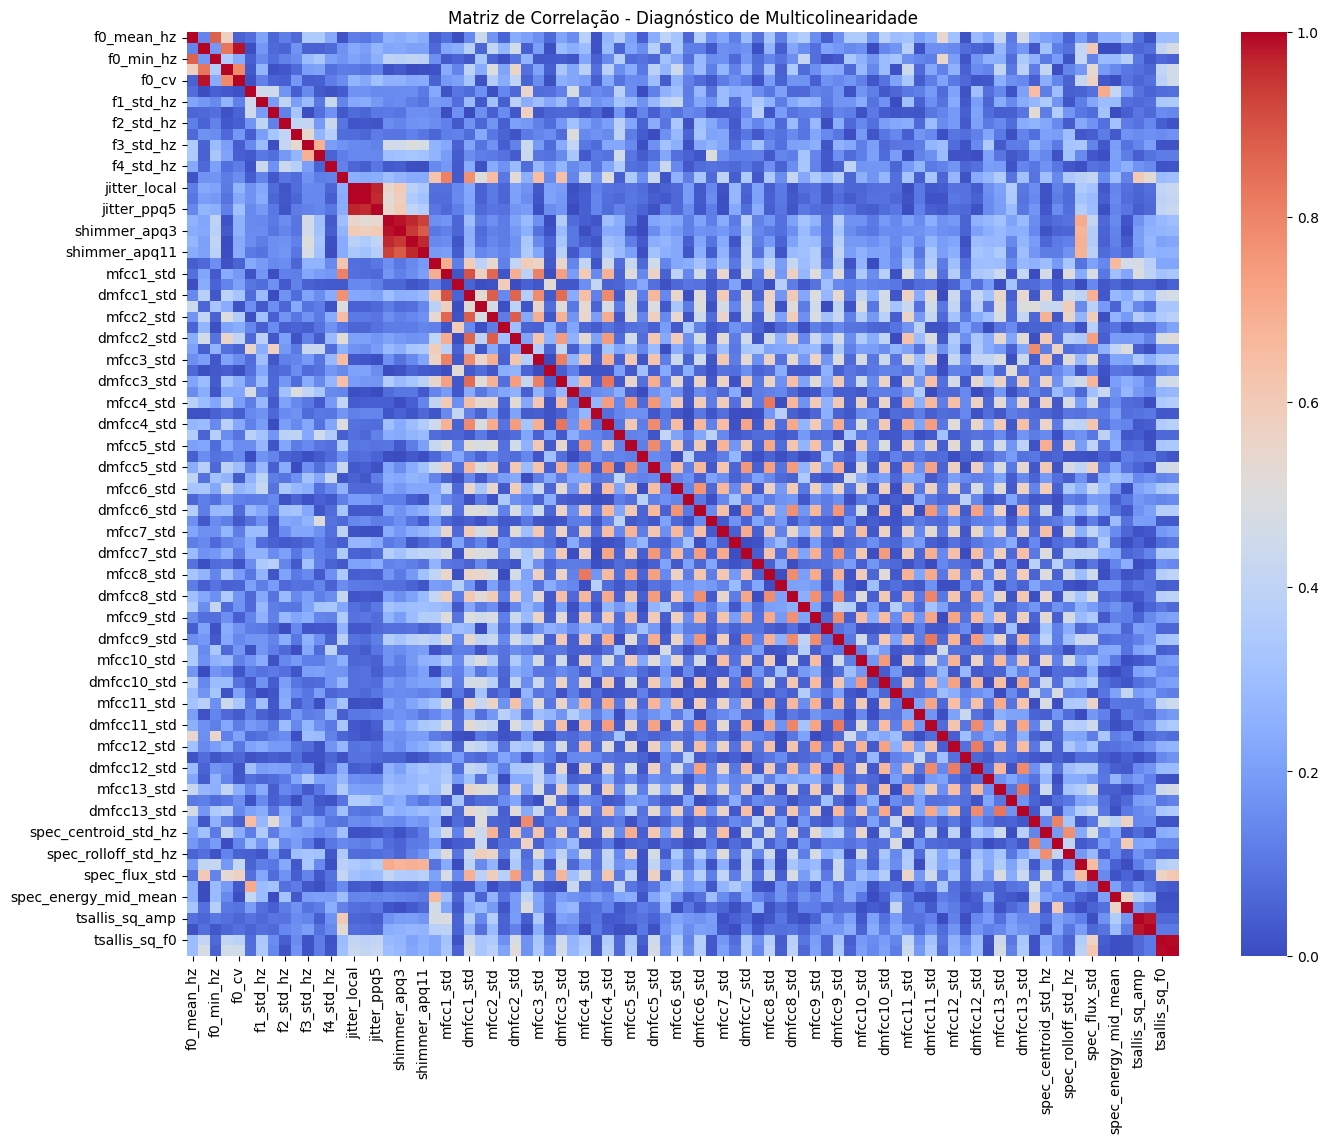


Número de colunas com correlação > 0.9: 9


In [13]:
# ============================================
# 7) analise de multicolinearidade
# ============================================

# Carregar o dataset imputado
df = pd.read_csv(DATASET_IMPUTED)

# Remover colunas não numéricas para o cálculo de correlação
cols_to_exclude = ['file_name', 'group', 'status', 'subject_id']
df_numeric = df.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_numeric.corr().abs()

# Selecionar o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a CORRELATION_THRESHOLD
highly_correlated = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]

# Preparar dados para visualização (top correlações)
unstacked_corr = upper.unstack().dropna()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Convertendo a Series para DataFrame para um CSV mais limpo
df_corr_export = sorted_corr.reset_index()
df_corr_export.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Salvar correlações em CSV
df_corr_export.to_csv(CORRELATION_LIST, index=False)

# Mostrar as 15 maiores correlações
print("Top 15 correlações mais altas:")
print(sorted_corr.head(15))

# Plotar um Heatmap das correlações
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Matriz de Correlação - Diagnóstico de Multicolinearidade")
plt.savefig(CORRELATION_GRAPH)
plt.show()

# Contagem de colunas problemáticas
print(f"\nNúmero de colunas com correlação > {CORRELATION_THRESHOLD}: {len(highly_correlated)}")

In [ ]:
# ============================================
# 8) Função: consenso de features
# ============================================
def get_consensus_features(rf_imp, xgb_imp, cat_imp, top_k=16):
    """Combine rankings of the 3 models to obtain consensus on the best features"""

   # Garante que os DataFrames de importância estejam ordenados para gerar o rank correto
    rf_ranked = rf_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    xgb_ranked = xgb_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    cat_ranked = cat_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)

    # Cria dicionários {nome_da_feature: posicao_no_rank}
    rf_rank_dict = {row['feature']: idx + 1 for idx, row in rf_ranked.iterrows()}
    xgb_rank_dict = {row['feature']: idx + 1 for idx, row in xgb_ranked.iterrows()}
    cat_rank_dict = {row['feature']: idx + 1 for idx, row in cat_ranked.iterrows()}
    
    all_features = set(rf_rank_dict.keys()) | set(xgb_rank_dict.keys()) | set(cat_rank_dict.keys())

    consensus_data = []
    for feature in all_features:
        # Busca a posição em cada modelo (se não existir, penaliza com o pior rank + 1)
        r_pos = rf_rank_dict.get(feature, len(rf_ranked) + 1)
        x_pos = xgb_rank_dict.get(feature, len(xgb_ranked) + 1)
        c_pos = cat_rank_dict.get(feature, len(cat_ranked) + 1)
        
        avg_rank = (r_pos + x_pos + c_pos) / 3
        consensus_data.append({
            'feature': feature,
            'rf_rank': r_pos,
            'xgb_rank': x_pos,
            'cat_rank': c_pos,
            'average_rank': avg_rank
        })
    
    # Ordena pelo rank médio (quanto menor, mais importante)
    df_consensus = pd.DataFrame(consensus_data).sort_values(by='average_rank').reset_index(drop=True)
    df_consensus.insert(0, 'final_rank', df_consensus.index + 1) # Insere a coluna de posição final

    return df_consensus

In [15]:
# Pré-processamento comum
preprocess = ImbPipeline(steps=[
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scale", RobustScaler())
])

X_proc = preprocess.fit_transform(X)


In [16]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_proc, y)
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)


# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_proc, y)
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


# CatBoost
cat = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=42
)
cat.fit(X_proc, y)
cat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

In [17]:
# Obter o DataFrame completo de consenso
df_ranking_completo = get_consensus_features(
    rf_imp=rf_importance,
    xgb_imp=xgb_importance,
    cat_imp=cat_importance,
    top_k=len(feature_cols) # Pega todas as features para o CSV
)

# Salvar o ranking detalhado em CSV
df_ranking_completo.to_csv(CONSENSUS_RANKING, index=False)
print(f"\nArquivo {CONSENSUS_RANKING} salvo com sucesso.")


Arquivo output/ranking_importancia_completo.csv salvo com sucesso.


In [18]:
# Seleciona TOP_K features principais para uso no modelo
top_features_list = df_ranking_completo['feature'].head(CONSENSUS_TOP_K).tolist()

# 3. Mostrar as TOP_K melhores no console
print(f"Top {CONSENSUS_TOP_K} features por consenso:")
print(df_ranking_completo[['final_rank', 'feature', 'average_rank']].head(CONSENSUS_TOP_K))

selected_features = top_features_list
missing = set(selected_features) - set(df.columns)
if missing:
    raise ValueError(f"Colunas selecionadas não encontradas no dataset: {missing}")


Top 16 features por consenso:
    final_rank                feature  average_rank
0            1             mfcc13_std      3.000000
1            2             mfcc2_mean      7.000000
2            3             mfcc11_std      8.333333
3            4          shimmer_local      9.000000
4            5             mfcc10_std     10.000000
5            6              mfcc1_std     10.333333
6            7              mfcc3_std     11.333333
7            8             dmfcc6_std     12.333333
8            9              mfcc9_std     12.666667
9           10            dmfcc3_mean     12.666667
10          11             dmfcc7_std     15.000000
11          12           dmfcc13_mean     16.333333
12          13  spec_centroid_mean_hz     16.333333
13          14            dmfcc11_std     18.000000
14          15            dmfcc13_std     20.000000
15          16    spec_rolloff_std_hz     20.333333


In [ ]:
# ============================================
#features selecionadas (Top-k)
# ============================================

# selected_features = [
#     "mfcc11_std",
#     "mfcc13_std", 
#     "mfcc1_std", 
#     "mfcc10_std", 
#     "dmfcc3_mean",
#     "dmfcc13_std",
#     "tsallis_sq_amp",
#     "mfcc9_std",
#     "shimmer_local",
#     "mfcc8_std",
#     "mfcc12_std",
#     "spec_rolloff_std_hz",
#     "mfcc1_mean",
#     "dmfcc13_mean",
#     "dmfcc7_std",
#     "shimmer_apq3",
# ]

In [20]:
# ============================================
# 10) Criar dataset reduzido (features + status + subject_id)
# ============================================
df_reduced = df[selected_features + ["status", "subject_id"]].copy()
print("\nShape dataset reduzido:", df_reduced.shape)



Shape dataset reduzido: (81, 18)


In [21]:
# ============================================
# 11) Salvar datasets (limpo e reduzido)
# ============================================

df_reduced.to_csv(DATASET_REDUCED, index=False)

df_imputed = pd.read_csv(DATASET_IMPUTED)
df_tsallis = pd.concat([df_reduced, df_imputed[tsallis_cols]], axis=1)

df_tsallis.to_csv(DATASET_TSALLIS, index=False)

print("\nArquivos salvos:")
print("-", DATASET_REDUCED)
print("-", DATASET_TSALLIS)


Arquivos salvos:
- output/dataset_reduced_top16.csv
- output/dataset_tsallis.csv
